In [1]:
import sys, os
from pathlib import Path

proj_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if proj_root not in sys.path:
    sys.path.insert(0, proj_root)

from weather_mind.mind import WeatherMind

In [16]:
import pandas as pd
import numpy as np
from pathlib import Path

df = pd.read_csv("../data/7410.csv")

N_IMAGES = 5
RANDOM_SEED = 42

TARGET_DATE = "9-26-2024"

df["rain_today_in"] = pd.to_numeric(df["rain_today_in"], errors="coerce")

df["date_raw"] = df["date"].astype(str).str.strip()
df["date_norm"] = pd.to_datetime(df["date_raw"], errors="coerce").dt.date

target_date = pd.to_datetime(TARGET_DATE, errors="coerce").date()

if pd.isna(target_date):
    raise ValueError(f"TARGET_DATE='{TARGET_DATE}' could not be parsed.")

day_df = df.loc[
    df["date_norm"] == target_date
].dropna(subset=["image_path"])

if day_df.empty:
    existing = (
        df["date_norm"]
        .dropna()
        .astype(str)
        .value_counts()
        .head(10)
        .index
        .tolist()
    )
    raise ValueError(
        f"No rows found for TARGET_DATE={TARGET_DATE}. "
        f"Sample available dates: {existing}"
    )

unique_rows = day_df.drop_duplicates(subset=["rain_today_in"], keep="first")
rows = unique_rows.reset_index(drop=True)

selected_rows = rows.loc[np.isclose(rows["rain_today_in"], 1.9)].head(1)

image_paths_raw = selected_rows["image_path"].dropna().tolist()

image_paths_clean = [
    p.replace("/7410/", "/7410_clean/").replace("\\7410\\", "\\7410_clean\\")
    for p in image_paths_raw
]

path_pairs = list(zip(map(Path, image_paths_raw), map(Path, image_paths_clean)))


In [17]:
print(path_pairs)

[(PosixPath('../data/7410/snap_7410_20240926_175115_831322df.jpg'), PosixPath('../data/7410_clean/snap_7410_20240926_175115_831322df.jpg'))]


In [20]:
questions = [
    "This image is from a weather station in Baxley, Georgia, on 2024-09-25 during hurricane Helene's passage over the Southeast US. Explain whether this looks like: a) pre-landfall outer bands, b) inner core/eyewall conditiond, c)decayong inland storm or d) a non-tropical system. Justify using texture, rainfall structure, trees, and lighting.",
    "Given that Helene was a major hurricane at landfall in Florida but weakened crossing into georgia, estimate whether this scene is more consistent with tropiccal-storm-force, gale-force, or sub-gale winds, and explain which visual cues you relied on (trees, debris, pole bending, spray, etc.).",
    "Assume the timestamp is afternoon of 2024‑09‑26 in Baxley, GA, when Helene was intensifying and approaching Florida’s Big Bend. Based only on the sky, rain bands, and motion cues, is this location likely: ahead of the main rain shield, inside a rainband, very near the core, or in the subsident dry slot? Explain briefly.",
    "Helene produced a large, asymmetric wind field with strong inland impacts. From this single frame, infer whether the strongest winds at this site are probably still ahead, occurring now, or already passed, and give a physical explanation.",
]

model_names = ["QWEN", "SMOLVLM", "MOONDREAM"]


================ IMAGE: snap_7410_20240926_175115_831322df.jpg ================



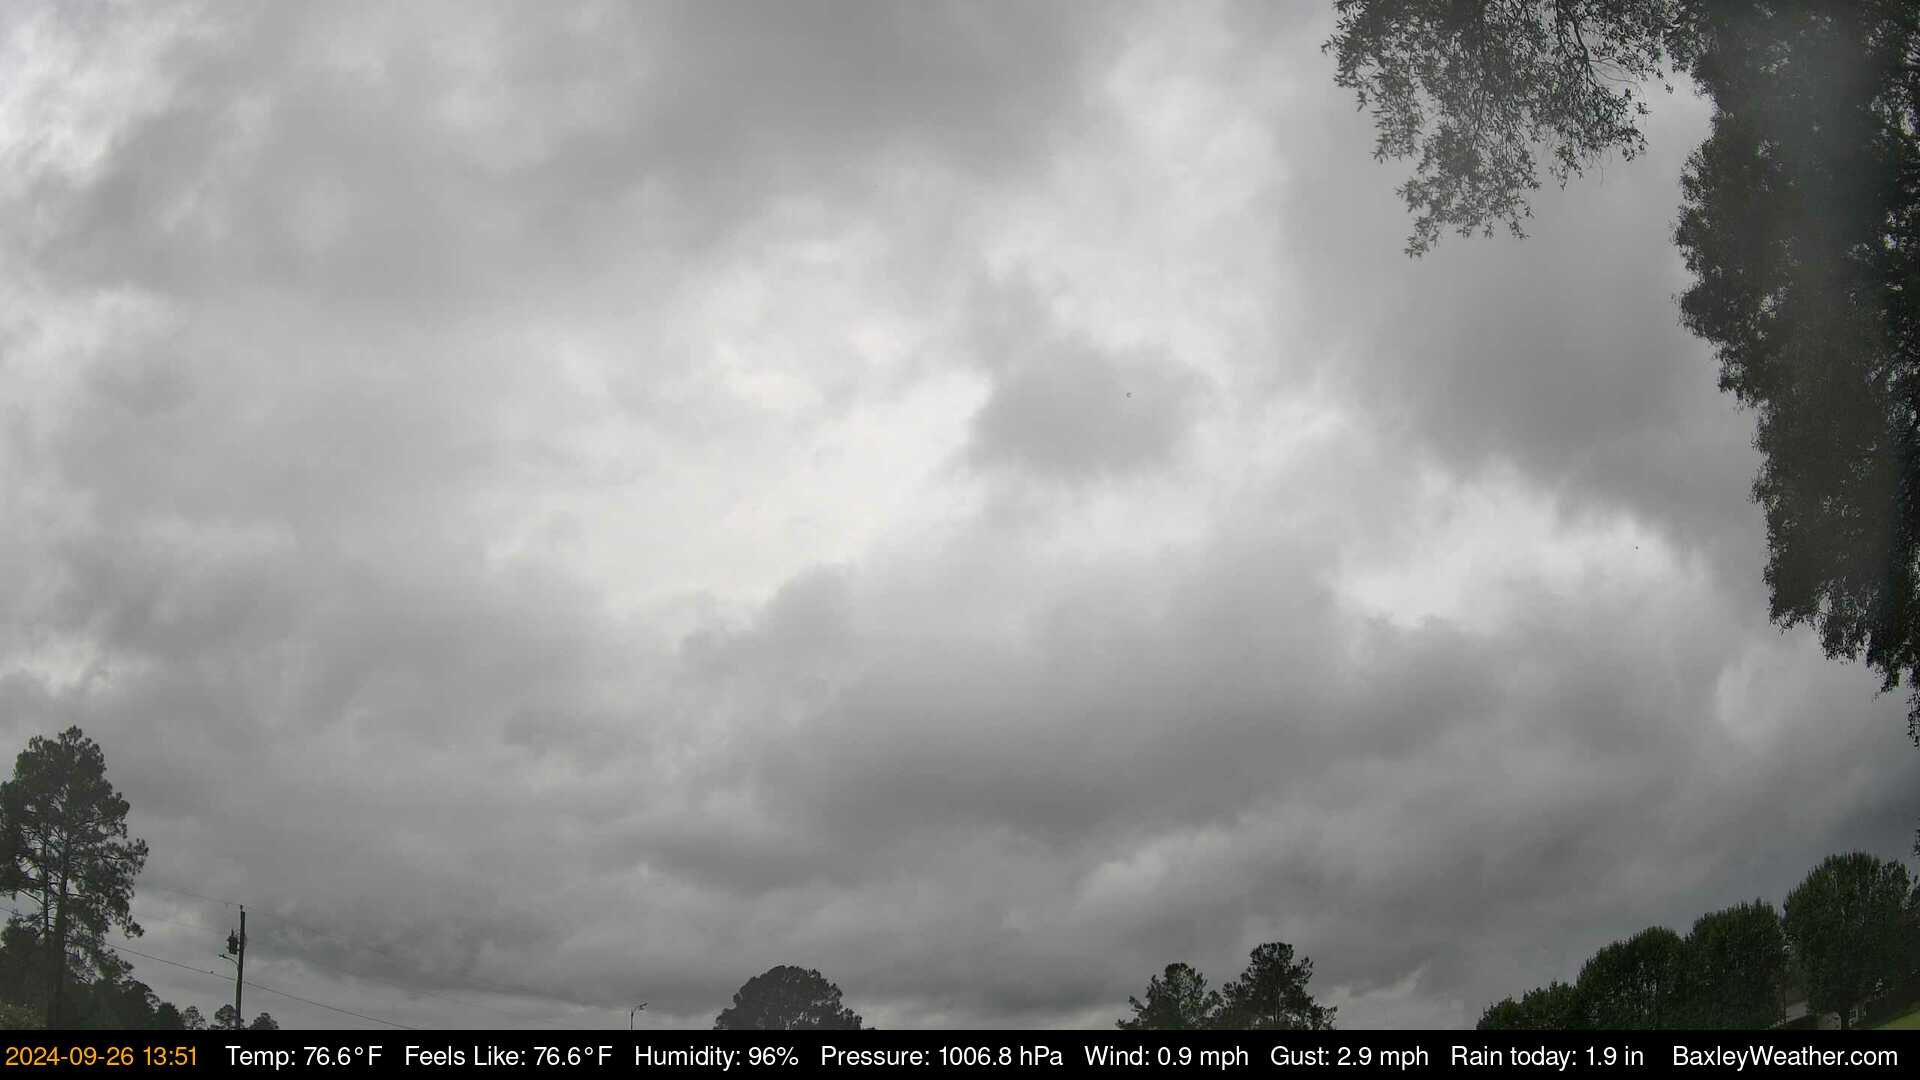


--- Weather station data for date = 2024-09-26 ---


,date,time,humidity_pct,temperature_f,feels_like_f,pressure_hpa,wind_speed_mph,gust_speed_mph,rain_today_in
1769,2024-09-26,00:19,93,77.5,77.5,1011.5,0.0,0.9,0.0
1770,2024-09-26,00:49,938,77.7,77.7,1010.8,0.9,2.0,0.0
1771,2024-09-26,01:19,94,77.5,77.5,1010.2,0.9,2.0,0.0
1772,2024-09-26,01:50,95,77.2,77.2,1010.1,2.0,2.9,0.2
1773,2024-09-26,02:20,95,76.8,76.8,1010.3,2.9,6.0,0.2
1774,2024-09-26,02:50,95,76.6,76.6,1009.9,0.9,4.0,0.2
1775,2024-09-26,03:20,95,75.9,75.9,1009.9,0.9,4.0,0.2
1776,2024-09-26,03:50,95,75.9,75.9,1009.8,0.9,2.0,0.3
1777,2024-09-26,04:20,96,75.9,75.9,1009.6,0.9,2.9,0.3
1778,2024-09-26,04:50,96,76.1,76.1,1009.2,0.9,4.0,0.3



---- MODEL: QWEN ----

=== Just one row of context at image timestamp 2024-09-26 13:51 ===

[QWEN] Q: This image is from a weather station in Baxley, Georgia, on 2024-09-25 during hurricane Helene's passage over the Southeast US. Explain whether this looks like: a) pre-landfall outer bands, b) inner core/eyewall conditiond, c)decayong inland storm or d) a non-tropical system. Justify using texture, rainfall structure, trees, and lighting.
A: Based on the measurements and the image provided, it appears that the weather conditions are consistent with those of a tropical storm or a hurricane. Here are the reasons: 1. **Texture of the Clouds**: The clouds in the image are thick and dark, which is characteristic of a tropical storm or hurricane. The clouds are not thin and wispy, which would be more typical of a non-tropical system. 2. **Rainfall Structure**: The image shows a significant amount of rainfall, which is consistent with the conditions of a tropical storm or hurricane. The rain

In [ ]:
from weather_mind.mind import WeatherMind
from PIL import Image
from IPython.display import display


mind = WeatherMind(metadata_csv="../data/7410.csv")

context_windows = [None, 1.0, 3.0, 6.0, 12.0]

all_outputs = []

for raw_path, clean_path in path_pairs:
    print(f"\n================ IMAGE: {raw_path.name} ================\n")

    if raw_path.exists():
        try:
            raw_img = Image.open(raw_path).convert("RGB")
            display(raw_img)
        except Exception as e:
            print(f"[error opening RAW] {raw_path}: {e}")
    else:
        print(f"[missing RAW] {raw_path}")

    if mind.metadata_df is not None:
        meta = mind.metadata_df.copy()
        img_name = raw_path.name

        matches = meta[meta["image_path"].astype(str).str.endswith(img_name)]

        if matches.empty:
            print(f"[warning] No metadata row found for image name {img_name}")
        else:
            day_date = matches.iloc[0]["date"]
            day_df = meta[meta["date"] == day_date].sort_values("time")

            cols_to_show = [
                "date",
                "time",
                "humidity_pct",
                "temperature_f",
                "feels_like_f",
                "pressure_hpa",
                "wind_speed_mph",
                "gust_speed_mph",
                "rain_today_in",
            ]

            day_df_small = day_df[cols_to_show]

            print(f"\n--- Weather station data for date = {day_date} ---")
            display(day_df_small)

    else:
        print("[warning] mind.metadata_df is None, cannot show CSV data.")

    img_for_model = str(clean_path)

    for model_name in model_names:
        print(f"\n---- MODEL: {model_name} ----\n")

        mind.load_model(model_name)

        for ctx_hours in context_windows:

            image_ts = mind.metadata_df.loc[
                mind.metadata_df["image_path"] == str(raw_path),
                "datetime",
            ].iloc[0]

            if ctx_hours is None:
                print(
                    f"=== Just one row of context at image timestamp "
                    f"{image_ts:%Y-%m-%d %H:%M} ===\n"
                )
            else:
                print(
                    f"=== Context window: last {ctx_hours} hours "
                    f"up to {image_ts:%Y-%m-%d %H:%M} ===\n"
                )

            for q in questions:
                formatted = mind.process_input(
                    img_for_model,
                    q,
                    use_metadata=True,
                    context_hours=ctx_hours,
                )

                print(formatted)
                print()

                all_outputs.append({
                    "image_raw": str(raw_path),
                    "image_clean": str(clean_path),
                    "model": model_name,
                    "question": q,
                    "context_hours": ctx_hours,
                    "formatted": formatted,
                })

    print()